In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from src.audio_mixer import mixer
import pandas as pd 

## Spectograms

In [2]:
audio_file_path = './data/demo/audio/common_voice_pl_20642745.mp3'
y, sr = librosa.load(audio_file_path)

In [104]:
audio_file_path = './data/demo/audio/common_voice_pl_20608830.mp3'
y, sr = librosa.load(audio_file_path)


In [105]:
S = np.abs(librosa.stft(y))


S_db = librosa.amplitude_to_db(S, ref=np.max)

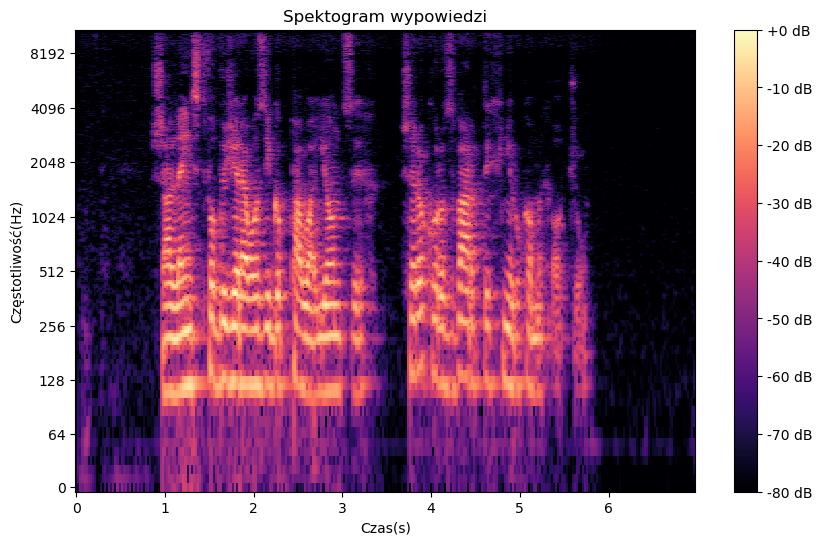

In [106]:
plt.figure(figsize=(10, 6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spektogram wypowiedzi')
plt.xlabel('Czas(s)')
plt.ylabel('Częstotliwość(Hz)')
plt.show()


In [95]:
noise_file_path = './data/demo/noise/30823-8-0-0.wav'

y, sr = librosa.load(noise_file_path)

S = np.abs(librosa.stft(y))


S_db = librosa.amplitude_to_db(S, ref=np.max)


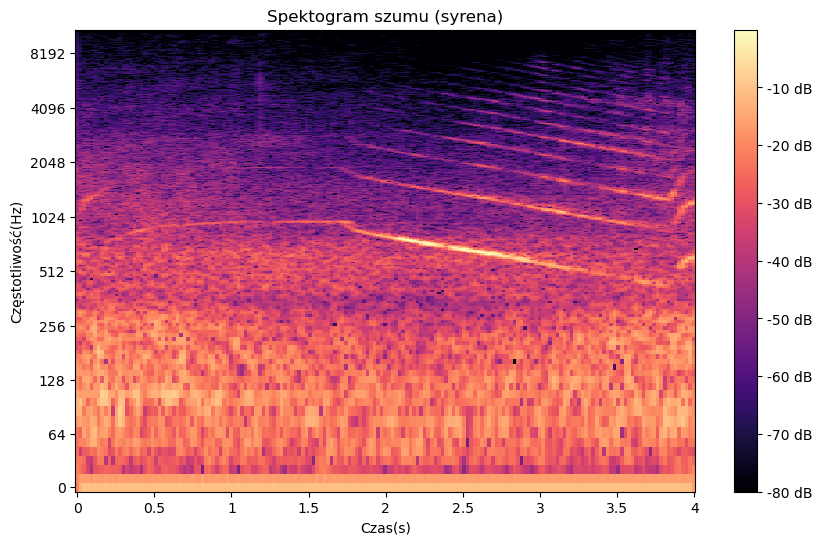

In [96]:
plt.figure(figsize=(10, 6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spektogram szumu (syrena)')
plt.xlabel('Czas(s)')
plt.ylabel('Częstotliwość(Hz)')
plt.show()


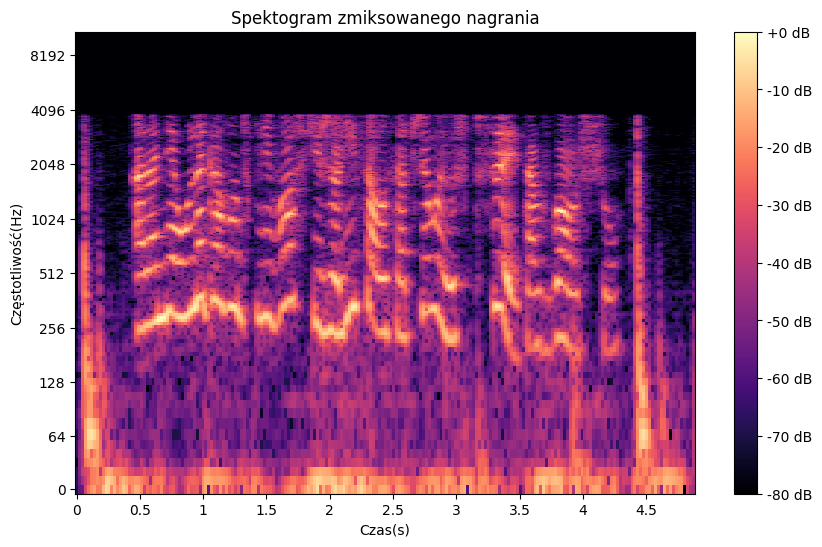

In [18]:
noise_file_path = './data/temporary/common_voice_pl_21642620.wav'


y, sr = librosa.load(noise_file_path)

S = np.abs(librosa.stft(y))


S_db = librosa.amplitude_to_db(S, ref=np.max)

plt.figure(figsize=(10, 6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spektogram zmiksowanego nagrania')
plt.xlabel('Czas(s)')
plt.ylabel('Częstotliwość(Hz)')
plt.show()


## Audiofile

In [3]:
def plot_waveforms(audio_file_paths, colors, legend_labels):
    plt.figure(figsize=(10, 6))

    for i, audio_file_path in enumerate(audio_file_paths):
        # Load the audio file
        y, sr = librosa.load(audio_file_path)
        
        # Time axis
        time = np.linspace(0, len(y) / sr, len(y))
        
        # Plot the waveform with the specified color and legend label
        plt.plot(time, y, color=colors[i], label=legend_labels[i],markersize=0.1,linewidth=1, alpha=1)
    
    # Adding labels and title
    plt.xlabel('Czas (s)')
    plt.ylabel('Amplituda')
    plt.title('Przebieg sygnału')
    
    # Adding grid
    plt.grid(True)
    
    # Display legend with custom labels
    plt.legend(loc='upper right')
    
    # Display the plot
    plt.show()
    

In [5]:
mixer('./data/demo/audio/common_voice_pl_21642620.mp3','./data/demo/noise/30823-8-0-0.wav', 50, './data/temporary/common_voice_pl_21642620.wav')

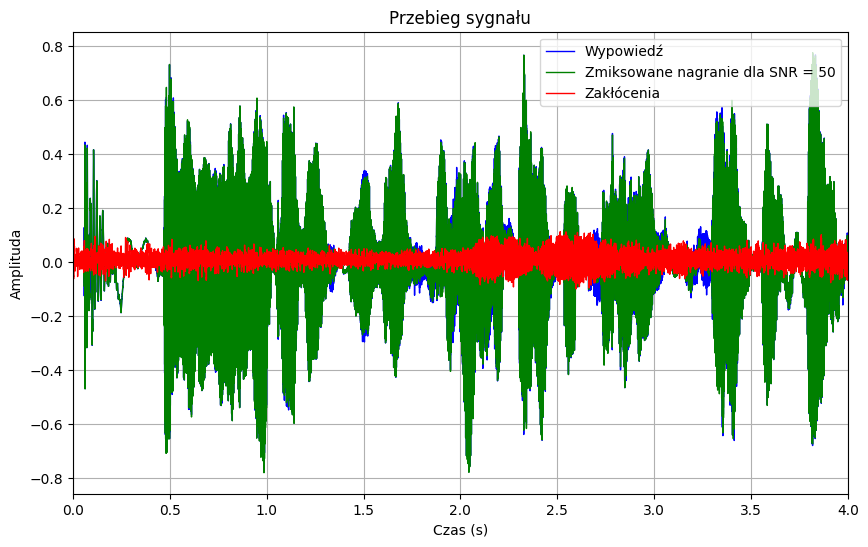

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import librosa

def plot_waveforms(audio_file_paths, colors, legend_labels):
    plt.figure(figsize=(10, 6))

    # Plot the first two waveforms
    for i in [1,2]:
        # Load the audio file
        y, sr = librosa.load(audio_file_paths[i])
        
        # Time axis
        time = np.linspace(0, len(y) / sr, len(y))
        
        # Plot the waveform with the specified color and legend label
        plt.plot(time, y, color=colors[i], label=legend_labels[i], markersize=0.1, linewidth=1, alpha=1)
    
    # Plot the third waveform separately to ensure it is on top
    y, sr = librosa.load(audio_file_paths[0])
    time = np.linspace(0, len(y) / sr, len(y))
    plt.plot(time, y, color=colors[0], label=legend_labels[0], markersize=0.1, linewidth=1, alpha=1)

    # Adding labels and title
    plt.xlabel('Czas (s)')
    plt.ylabel('Amplituda')
    plt.title('Przebieg sygnału')
    
    # Adding grid
    plt.grid(True)
    
    # Display legend with custom labels
    plt.legend(loc='upper right')

    plt.xlim([0,4])
    
    # Display the plot
    plt.show()

# Audio file paths
audio_file_paths = [ 
    './data/demo/noise/30823-8-0-0.wav', 
    './data/demo/audio/common_voice_pl_21642620.mp3',
    './data/temporary/common_voice_pl_21642620.wav',
]

# Colors for each waveform
colors = ['red', 'blue', 'green']

# Legend labels for each waveform
legend_labels = [ 'Zakłócenia','Wypowiedź','Zmiksowane nagranie dla SNR = 50']

# Plot the waveforms
plot_waveforms(audio_file_paths, colors, legend_labels)


In [5]:
batch_df = pd.read_csv('./images_to_batch/wykres_1.csv')

In [6]:
batch_df

,Wall time,Step,Value
0,1.711498e+09,25,1.5060
1,1.711498e+09,50,1.4442
2,1.711498e+09,75,1.1312
3,1.711499e+09,100,0.8122
4,1.711499e+09,125,0.6313
...,...,...,...
155,1.711570e+09,3900,0.0001
156,1.711571e+09,3925,0.0001
157,1.711571e+09,3950,0.0001
158,1.711572e+09,3975,0.0001


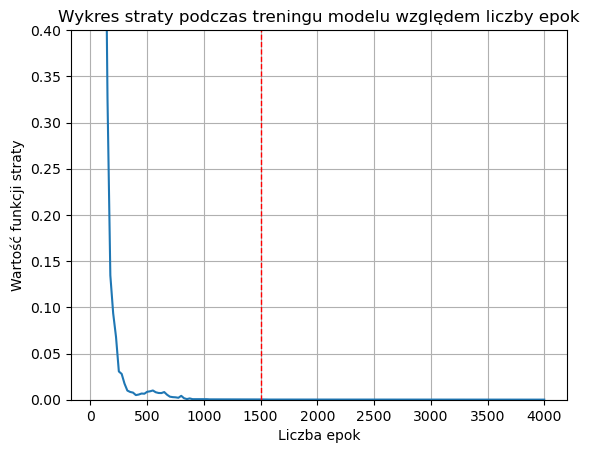

In [35]:
plt.plot(batch_df['Step'],batch_df['Value'])
plt.xlabel("Liczba epok")
plt.ylabel('Wartość funkcji straty')
plt.title("Wykres straty podczas treningu modelu względem liczby epok")
plt.axvline(1500, color='red', linestyle='--', linewidth=1)
plt.ylim(0, 0.4)
plt.grid()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(1550, 0.09200000000000001, 'Przyjęta granica nauki modelu')

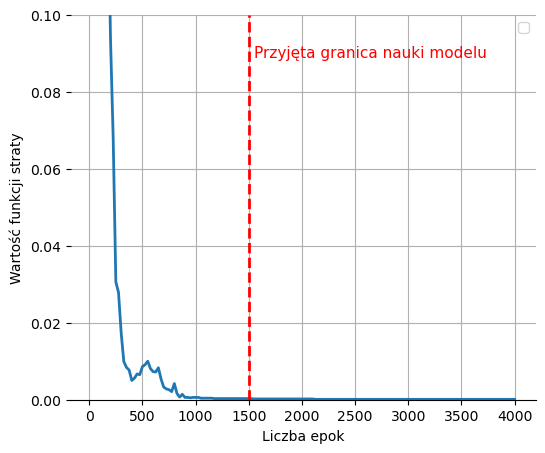

In [74]:
fig, ax = plt.subplots(figsize=(6, 5))

# Plot the baseline
ax.plot(
    label="Baseline",
    color="lightgray",
    linestyle="--",
    linewidth=1,
)


ax.plot(batch_df['Step'],batch_df['Value'], linewidth=2)

# -------------------BEGIN-CHANGES------------------------
# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_ticks_position("bottom")
# --------------------END CHANGES------------------------

ax.set_xlabel("Liczba epok")
ax.set_ylabel('Wartość funkcji straty')

ax.axvline(1500, color='red', linestyle='--', linewidth=2)
ax.set_ylim(0, 0.1)
ax.legend()
ax.grid()
ax.text(1550, ax.get_ylim()[1] * 0.92, 'Przyjęta granica nauki modelu', color='red', ha='left', va='top', rotation=0, fontsize=11)

In [59]:
batch_time_df = pd.read_csv('./images_to_batch/wykres_2.csv')
batch_time_df

,Wall time,Step,Value
0,1.711498e+09,25,1.5060
1,1.711498e+09,50,1.4442
2,1.711498e+09,75,1.1312
3,1.711499e+09,100,0.8122
4,1.711499e+09,125,0.6313
...,...,...,...
155,1.711570e+09,3900,0.0001
156,1.711571e+09,3925,0.0001
157,1.711571e+09,3950,0.0001
158,1.711572e+09,3975,0.0001


In [60]:
batch_time_df['Wall_times_sec'] = batch_time_df['Wall time'] - batch_time_df['Wall time'][0]

In [62]:
batch_time_df['Wall_times_min'] = batch_time_df['Wall_times_sec'] / 60
batch_time_df['Wall_times_hour'] = batch_time_df['Wall_times_min'] / 60

In [63]:
batch_time_df['Wall_times_hour']

0       0.000000
1       0.134913
2       0.264631
3       0.394448
4       0.524155
         ...    
155    20.250065
156    20.378621
157    20.507445
158    20.636026
159    20.764731
Name: Wall_times_hour, Length: 160, dtype: float64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(8.097, 0.09200000000000001, 'Czas treningu do granicy 8 godz 5 min')

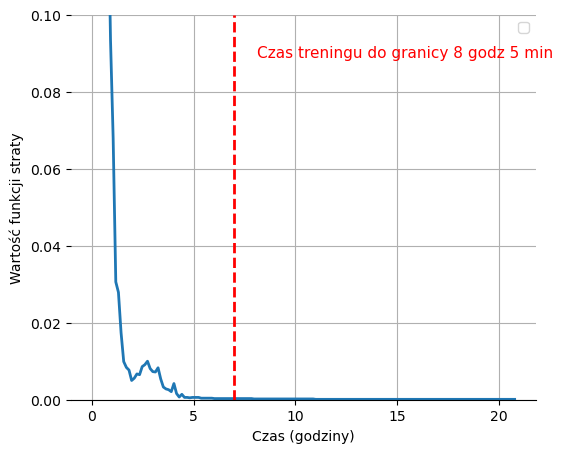

In [73]:

fig, ax = plt.subplots(figsize=(6, 5))

# Plot the baseline
ax.plot(
    label="Baseline",
    color="lightgray",
    linestyle="--",
    linewidth=1,
)


ax.plot(batch_time_df['Wall_times_hour'],batch_df['Value'], linewidth=2)

# -------------------BEGIN-CHANGES------------------------
# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

# Only show ticks on the left and bottom spines
ax.yaxis.set_ticks_position("left")
ax.xaxis.set_ticks_position("bottom")
# --------------------END CHANGES------------------------

ax.set_xlabel("Czas (godziny)")
ax.set_ylabel('Wartość funkcji straty')
ax.axvline(7, color='red', linestyle='--', linewidth=2)
ax.set_ylim(0, 0.1)
ax.legend()
ax.grid()
ax.text(8.097, ax.get_ylim()[1] * 0.92, 'Czas treningu do granicy 8 godz 5 min', color='red', ha='left', va='top', rotation=0, fontsize=11)

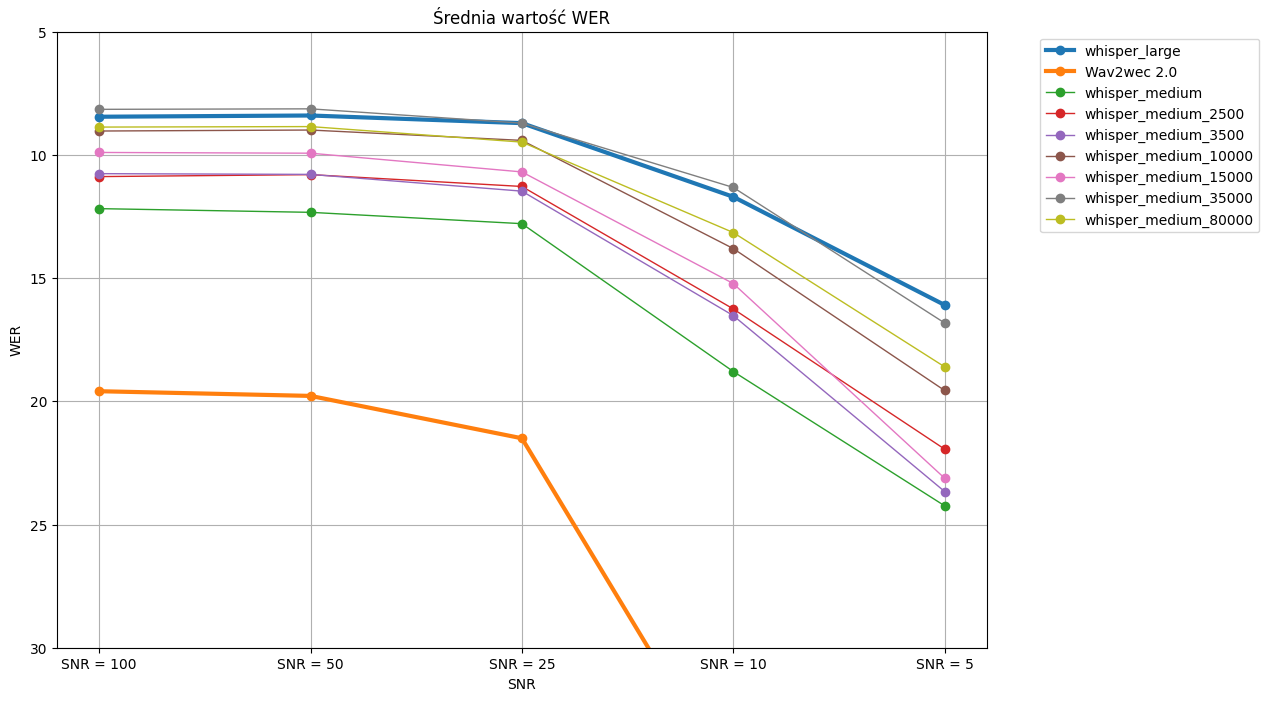

In [18]:
wykres = pd.read_csv('tren_evalu.csv')
wykres = wykres.iloc[:9, :6]

# Set the first column as the index to label each row
wykres.set_index('Unnamed: 0', inplace=True)

# Transpose the DataFrame to make rows as columns and columns as rows
df_transposed = wykres.T    
# Plotting each row as a separate line
plt.figure(figsize=(12, 8))

# Plotting each line for each column (original row)
for row in wykres.index:
    if row == 'whisper_large' or row == 'Wav2wec 2.0':
        # Make the 'whisper_large' and 'Wav2wec 2.0' lines thicker
        plt.plot(wykres.columns, wykres.loc[row], marker='o', label=row, linewidth=3)
    else:
        # Standard line width for other lines
        plt.plot(wykres.columns, wykres.loc[row], marker='o', label=row, linewidth=1)

plt.ylim(5, 30)

plt.gca().invert_yaxis()
# Adding title and labels
plt.title('Średnia wartość WER')
plt.xlabel('SNR')
plt.ylabel('WER')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

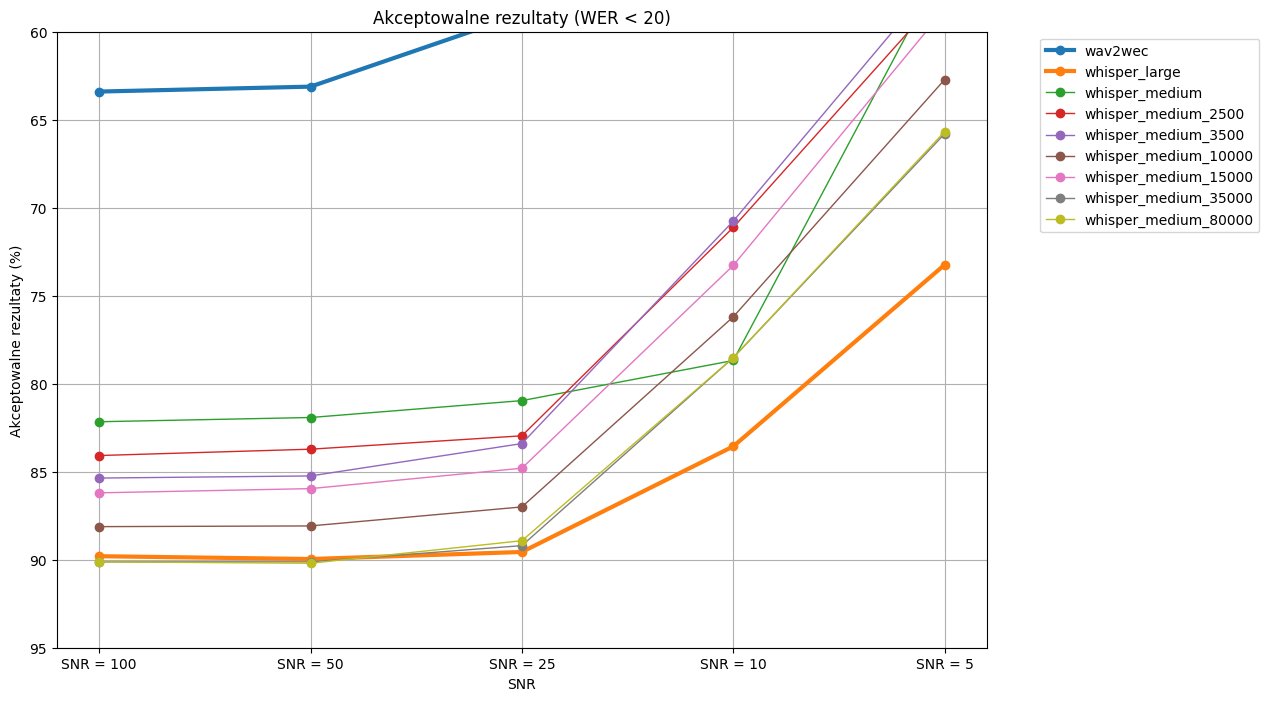

In [28]:
wykres = pd.read_csv('tren_wyniki_akce.csv')
wykres = wykres.iloc[:9, :6]

# Set the first column as the index to label each row
wykres.set_index('Unnamed: 0', inplace=True)

# Transpose the DataFrame to make rows as columns and columns as rows
df_transposed = wykres.T    
# Plotting each row as a separate line
plt.figure(figsize=(12, 8))

# Plotting each line for each column (original row)
for row in wykres.index:
    if row == 'whisper_large' or row == 'wav2wec':
        # Make the 'whisper_large' and 'Wav2wec 2.0' lines thicker
        plt.plot(wykres.columns, wykres.loc[row], marker='o', label=row, linewidth=3)
    else:
        # Standard line width for other lines
        plt.plot(wykres.columns, wykres.loc[row], marker='o', label=row, linewidth=1)

plt.ylim(60, 95)

plt.gca().invert_yaxis()
# Adding title and labels
plt.title('Akceptowalne rezultaty (WER < 20)')
plt.xlabel('SNR')
plt.ylabel('Akceptowalne rezultaty (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [3]:
import pandas as pd
from jiwer import wer
import jiwer
import matplotlib.pyplot as plt 
from src.data_plotting import histogram_plotting, boxplot_plotting, kde_plotting, plot_model_comparison
from src.statistics import advanced_statistics, word_frequency, word_frequency, advanced_statistics_cer, advanced_statistics_wil
import nltk
from nltk.tokenize import word_tokenize
from evaluate import load

/var/data/python/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_wav2wec = pd.read_parquet('./data/parquets/wav2wec_wer.parquet.gzip')
df_whisper_large = pd.read_parquet('./data/parquets/Whisper_SNR_WER.gzip')

In [13]:
wav2wec_stats = advanced_statistics_cer(df_wav2wec,'Wav2wec_SNR','sentences',2)
wav2wec_stats

,Model_SNR_100,Model_SNR_50,Model_SNR_25,Model_SNR_10,Model_SNR_5,Model_SNR_0.1,Model_SNR_-1
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,7.35,7.39,7.88,13.25,22.59,40.62,45.00
std,15.00,15.10,15.33,17.96,21.95,29.10,30.49
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.19,1.20,1.49,3.88,7.69,15.81,18.42
50%,3.76,3.85,4.17,9.52,18.18,39.78,46.98
75%,10.22,10.27,11.11,17.59,32.57,62.71,68.98
max,428.12,437.50,428.12,425.00,377.50,397.50,392.50
mean without 2%,6.09,6.14,6.58,11.72,20.95,38.90,43.28


In [12]:
whisper_stats = advanced_statistics_cer(df_wh   isper_large, 'WER_audio_SNR','ref_orig',2)
whisper_stats

,Model_SNR_100_path,Model_SNR_50_path,Model_SNR_25_path,Model_SNR_10_path,Model_SNR_5_path,Model_SNR_0.1_path,Model_SNR_-1_path,Model_SNR_-3_path,Model_SNR_-10_path
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,5.43,5.43,5.50,6.72,8.71,15.40,19.92,24.44,65.33
std,16.96,16.92,15.17,16.49,17.50,37.33,103.64,58.27,147.26
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,1.61,2.17,3.45,12.33
50%,1.19,1.19,1.28,2.35,4.17,9.68,11.42,14.45,53.68
75%,6.87,6.91,7.29,9.52,11.92,19.10,22.32,32.79,88.03
max,440.62,440.62,440.62,440.62,450.00,1165.15,4756.67,1733.85,4042.11
mean without 2%,3.99,4.01,4.14,5.18,7.04,12.76,15.11,20.53,49.75


/home/eryk/Documents/GitHub/ASR-SNR-Research/src/data_plotting.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_1_line.append(data_1_line_temp[i])
/home/eryk/Documents/GitHub/ASR-SNR-Research/src/data_plotting.py:73: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_2_line.append(data_2_line_temp[i])


[np.float64(3.99), np.float64(4.01), np.float64(4.14), np.float64(5.18), np.float64(7.04), np.float64(12.76)]
[np.float64(6.09), np.float64(6.14), np.float64(6.58), np.float64(11.72), np.float64(20.95), np.float64(38.9)]
['100', '50', '25', '10', '5', '0.1']


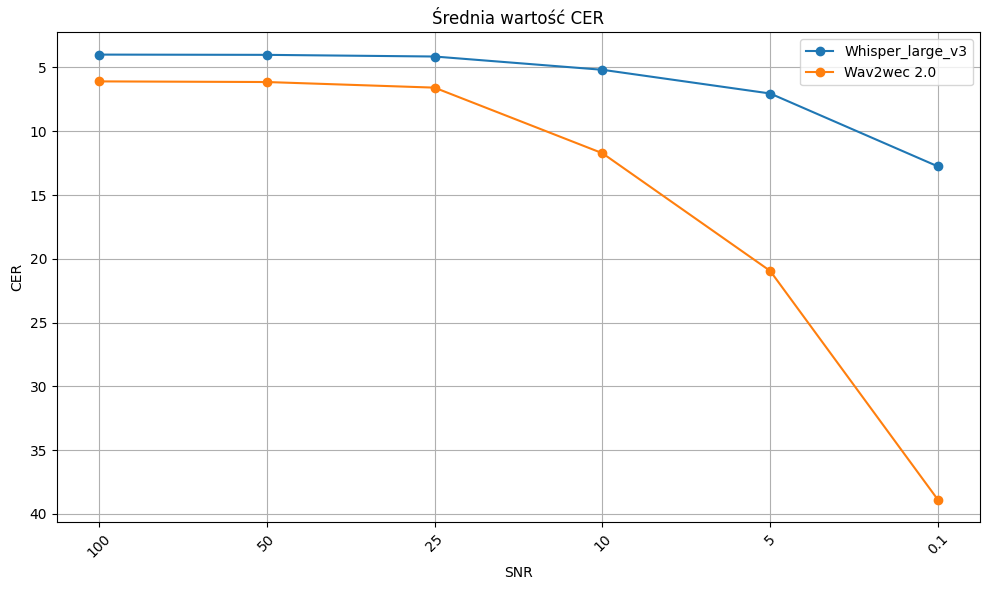

In [14]:
# Renaming columns
for col in whisper_stats.columns:
    if col.endswith('_path'):
        # Removing the '_path' suffix
        new_name = col[:-5]
        whisper_stats.rename(columns={col: new_name}, inplace=True)



# Deleting low SNR columns
whisper_stats = whisper_stats.drop(columns=['Model_SNR_-1', 'Model_SNR_-3','Model_SNR_-10'])

wav2wec_stats = wav2wec_stats.drop(columns = ['Model_SNR_-1'])

plot_model_comparison(whisper_stats,wav2wec_stats,'mean without 2%','Whisper_large_v3', 'Wav2wec 2.0', 'CER', 'Średnia wartość CER', inverted = True)

In [15]:
plocik = pd.read_csv('cer_wyniki.csv')

In [16]:
plocik

,Unnamed: 0,SNR = 100,SNR = 50,SNR = 25,SNR = 10,SNR = 5
0,wav2wec,6.09,6.14,6.58,11.72,20.95
1,whisper_large,3.99,4.01,4.14,5.18,7.04
2,whisper_medium,5.01,5.03,5.24,6.95,9.77
3,whisper_medium_2500,2.88,2.87,3.05,4.85,7.50
4,whisper_medium_3500,2.85,2.85,3.15,5.25,8.11
5,whisper_medium_10000,2.39,2.37,2.51,4.15,6.71
6,whisper_medium_15000,2.63,2.63,2.84,4.52,7.20
7,whisper_medium_35000,2.19,2.20,2.40,3.91,6.38
8,whisper_medium_80000,2.21,2.19,2.38,4.09,6.61


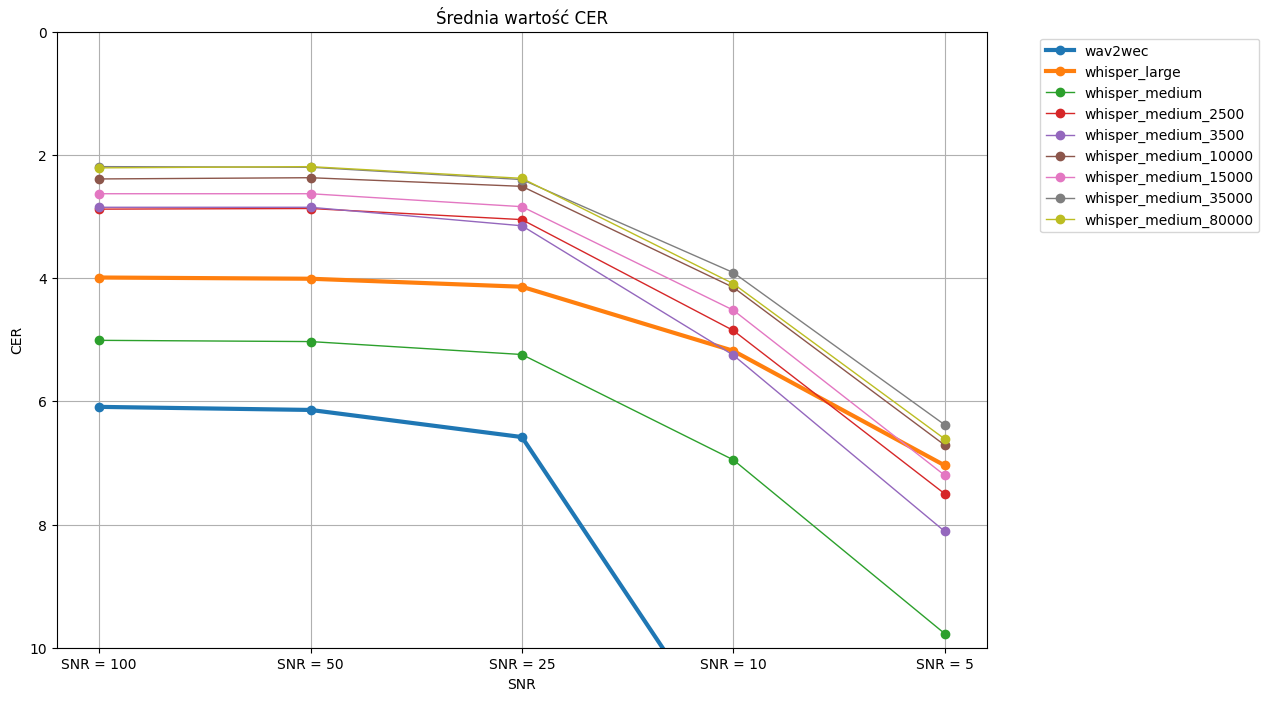

In [20]:
wykres = pd.read_csv('cer_wyniki.csv')
# Set the first column as the index to label each row
wykres.set_index('Unnamed: 0', inplace=True)

# Transpose the DataFrame to make rows as columns and columns as rows
df_transposed = wykres.T    
# Plotting each row as a separate line
plt.figure(figsize=(12, 8))

# Plotting each line for each column (original row)
for row in wykres.index:
    if row == 'whisper_large' or row == 'wav2wec':
        # Make the 'whisper_large' and 'Wav2wec 2.0' lines thicker
        plt.plot(wykres.columns, wykres.loc[row], marker='o', label=row, linewidth=3)
    else:
        # Standard line width for other lines
        plt.plot(wykres.columns, wykres.loc[row], marker='o', label=row, linewidth=1)

plt.ylim(0, 10)

plt.gca().invert_yaxis()
# Adding title and labels
plt.title('Średnia wartość CER')
plt.xlabel('SNR')
plt.ylabel('CER')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()